
Task 1 - EDA on Retail Sales Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("retail_sales_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn information:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("\nDate range:")
print("Start:", df["Date"].min().date())
print("End:", df["Date"].max().date())

Dataset shape: (1000, 9)

Column information:
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0

Date range:
Start: 2023-01-01
End: 2024-01-01


In [4]:

numeric_cols = df.select_dtypes(include=np.number).columns

descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std()
}).round(2)

display(descriptive_stats)

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.50,500.5,1.0,288.82
Age,41.39,42.0,43.0,13.68
Quantity,2.51,3.0,4.0,1.13
Price per Unit,179.89,50.0,50.0,189.68
Total Amount,456.00,135.0,50.0,560.00


,Date,Total Amount,Month
0,2023-01,35450,2023-01-01
1,2023-02,44060,2023-02-01
2,2023-03,28990,2023-03-01
3,2023-04,33870,2023-04-01
4,2023-05,53150,2023-05-01
5,2023-06,36715,2023-06-01
6,2023-07,35465,2023-07-01
7,2023-08,36960,2023-08-01
8,2023-09,23620,2023-09-01
9,2023-10,46580,2023-10-01


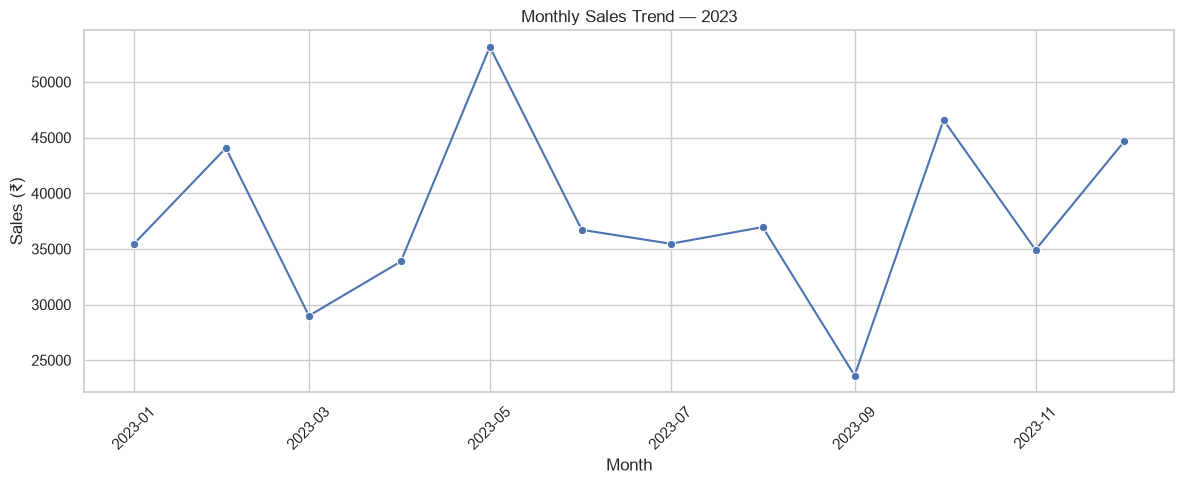

In [5]:

monthly_sales = (
    df[df["Date"].dt.year == 2023]
    .groupby(df["Date"].dt.to_period("M"))["Total Amount"]
    .sum()
    .reset_index()
)

monthly_sales["Month"] = monthly_sales["Date"].dt.to_timestamp()

display(monthly_sales)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Total Amount",
    marker="o"
)

plt.title("Monthly Sales Trend — 2023")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Quarter,Total Amount
0,2023Q1,108500
1,2023Q2,123735
2,2023Q3,96045
3,2023Q4,126190


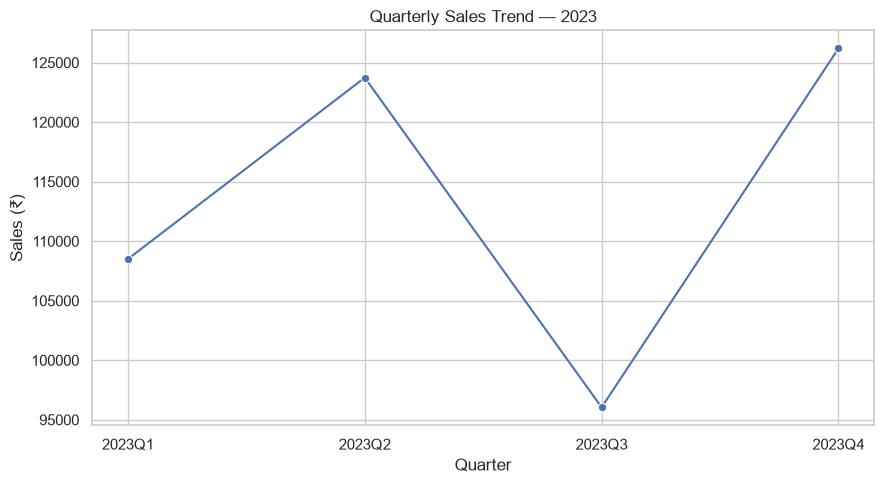

In [6]:
# Quarterly sales analysis 

quarterly_sales = (
    df[df["Date"].dt.year == 2023]
    .assign(Quarter=df["Date"].dt.to_period("Q"))
    .groupby("Quarter")["Total Amount"]
    .sum()
    .reset_index()
)

quarterly_sales["Quarter"] = quarterly_sales["Quarter"].astype(str)

display(quarterly_sales)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=quarterly_sales,
    x="Quarter",
    y="Total Amount",
    marker="o"
)

plt.title("Quarterly Sales Trend — 2023")
plt.xlabel("Quarter")
plt.ylabel("Sales (₹)")
plt.tight_layout()
plt.show()

In [7]:

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["Under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)


age_group_sales = (
    df.groupby("Age Group", observed=False)["Total Amount"]
    .sum()
    .reset_index()
)


display(age_group_sales)

,Age Group,Total Amount
0,Under 18,0
1,18-24,74650
2,25-34,97090
3,35-44,96835
4,45-54,97235
5,55-64,90190
6,65+,0


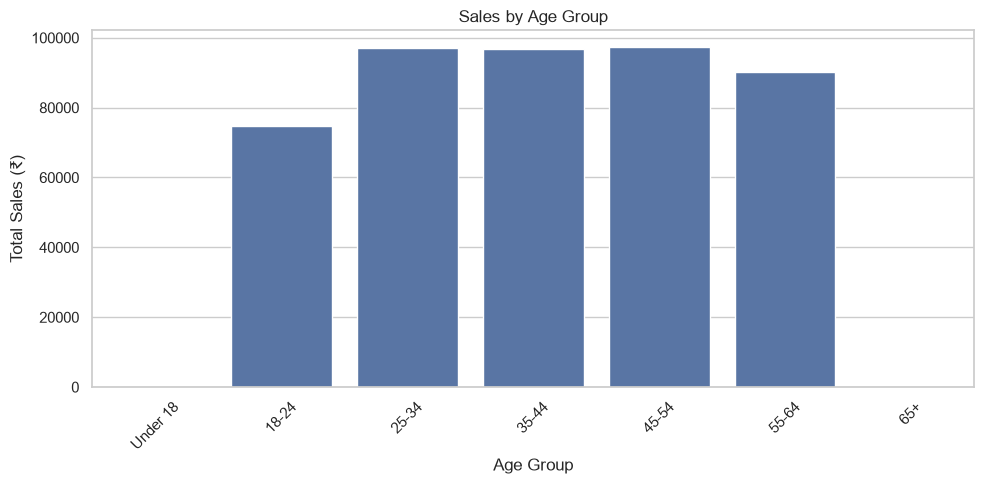

In [8]:


plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_group_sales,
    x="Age Group",
    y="Total Amount"
)

plt.title("Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:

gender_sales = (
    df.groupby("Gender")["Total Amount"]
    .sum()
    .reset_index()
)


display(gender_sales)

,Gender,Total Amount
0,Female,232840
1,Male,223160


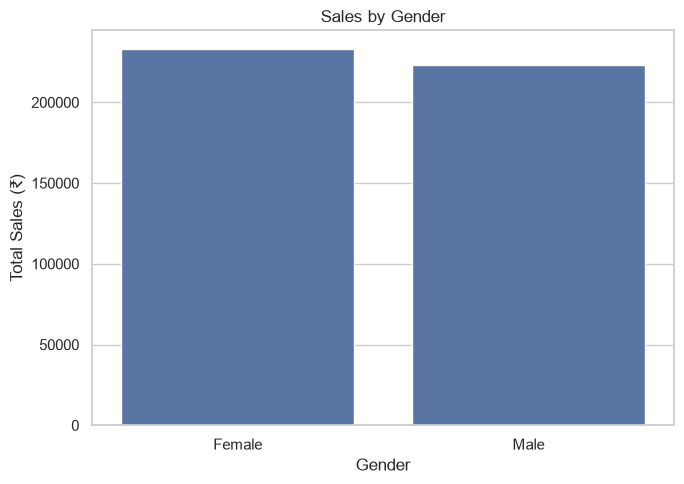

In [10]:


plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_sales,
    x="Gender",
    y="Total Amount"
)

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales (₹)")
plt.tight_layout()
plt.show()

In [11]:

category_sales = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(category_sales)

,Product Category,Total Amount
0,Electronics,156905
1,Clothing,155580
2,Beauty,143515


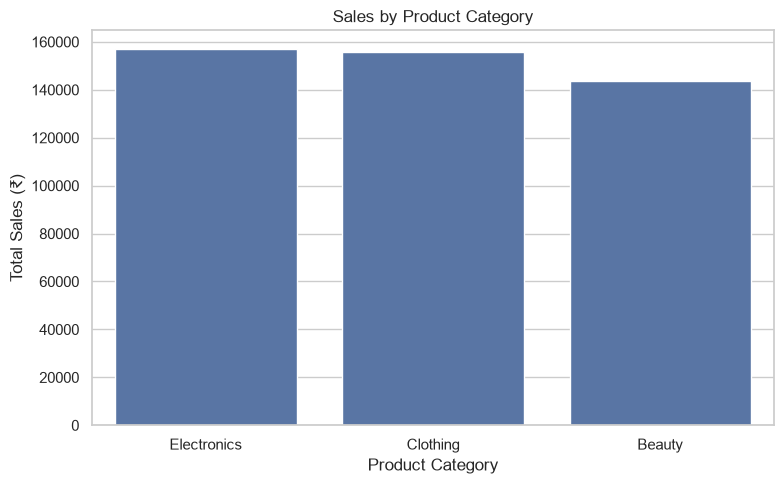

In [12]:

plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_sales,
    x="Product Category",
    y="Total Amount"
)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales (₹)")
plt.tight_layout()
plt.show()

In [13]:

top_10_transactions = (
    df[
        [
            "Transaction ID",
            "Date",
            "Customer ID",
            "Gender",
            "Age",
            "Product Category",
            "Quantity",
            "Price per Unit",
            "Total Amount"
        ]
    ]
    .sort_values("Total Amount", ascending=False)
    .head(10)
)

display(top_10_transactions)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
945,946,2023-05-08,CUST946,Male,62,Electronics,4,500,2000
71,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
576,577,2023-02-13,CUST577,Male,21,Beauty,4,500,2000
571,572,2023-04-20,CUST572,Male,31,Clothing,4,500,2000
268,269,2023-02-01,CUST269,Male,25,Clothing,4,500,2000
502,503,2023-10-25,CUST503,Male,45,Beauty,4,500,2000
926,927,2023-06-24,CUST927,Male,43,Electronics,4,500,2000
252,253,2023-08-31,CUST253,Female,53,Clothing,4,500,2000
546,547,2023-03-07,CUST547,Male,63,Clothing,4,500,2000


In [14]:
correlation_data = df[
    ["Age", "Quantity", "Price per Unit", "Total Amount"]
]


correlation_matrix = correlation_data.corr()


display(correlation_matrix.round(2))

,Age,Quantity,Price per Unit,Total Amount
Age,1.00,-0.02,-0.04,-0.06
Quantity,-0.02,1.00,0.02,0.37
Price per Unit,-0.04,0.02,1.00,0.85
Total Amount,-0.06,0.37,0.85,1.00


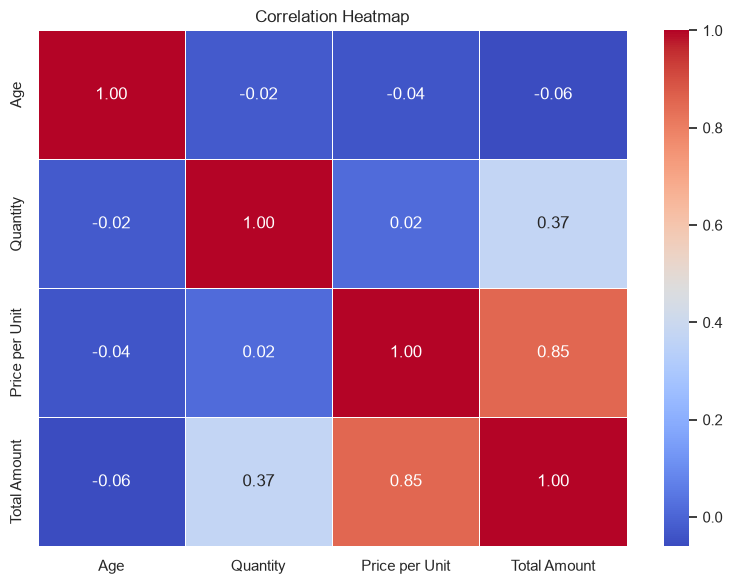

In [15]:
#correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [16]:

age_category_sales = (
    df.groupby(
        ["Age Group", "Product Category"],
        observed=False
    )["Total Amount"]
    .sum()
    .unstack()
)

display(age_category_sales)

Product Category,Beauty,Clothing,Electronics
Age Group,,,
Under 18,0,0,0
18-24,28905,22160,23585
25-34,28540,41640,26910
35-44,29450,30925,36460
45-54,35950,29545,31740
55-64,20670,31310,38210
65+,0,0,0


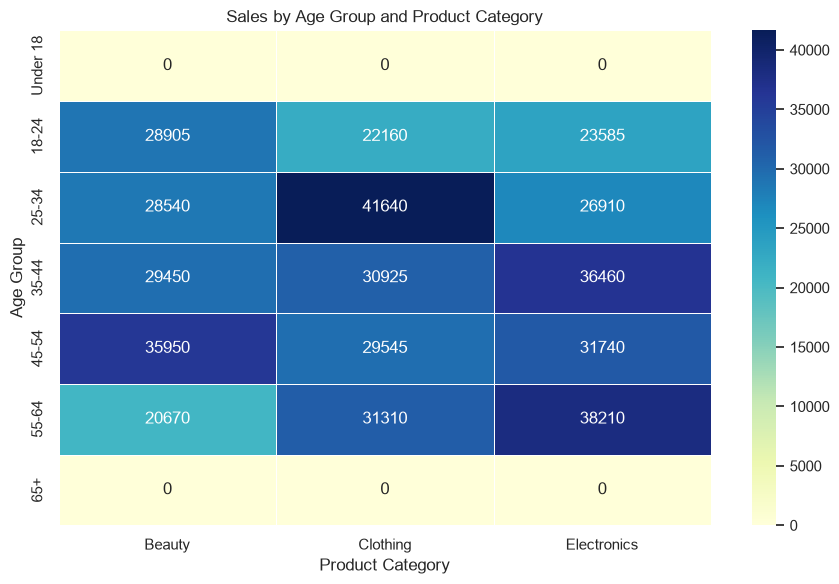

In [17]:
# age group and product category heatmap

plt.figure(figsize=(9, 6))

sns.heatmap(
    age_category_sales,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Sales by Age Group and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

In [19]:

avg_transaction_age = (
    df.groupby("Age Group", observed=False)["Total Amount"]
    .mean()
    .reset_index()
)

# Display the result
display(avg_transaction_age.round(2))

,Age Group,Total Amount
0,Under 18,NaN
1,18-24,501.01
2,25-34,478.28
3,35-44,467.80
4,45-54,432.16
5,55-64,417.55
6,65+,NaN


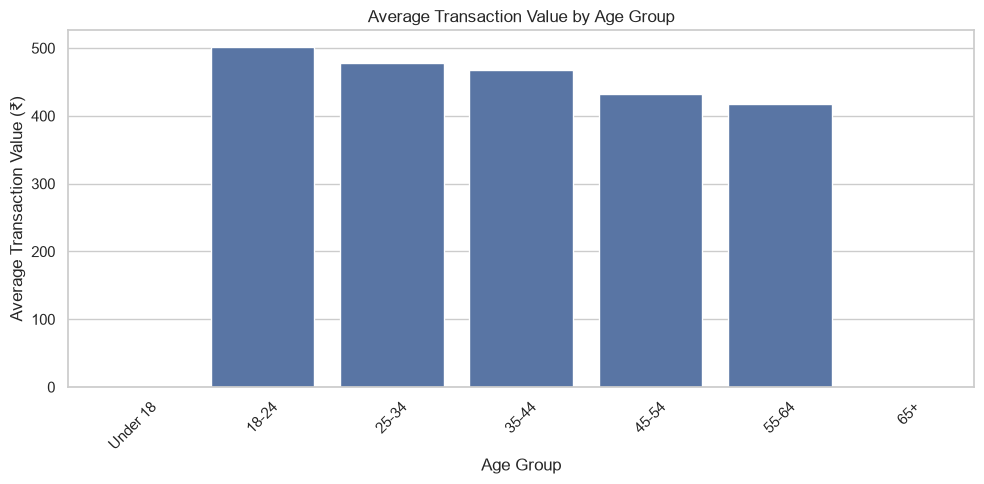

In [20]:

plt.figure(figsize=(10, 5))

sns.barplot(
    data=avg_transaction_age,
    x="Age Group",
    y="Total Amount"
)

plt.title("Average Transaction Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Value (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Key Findings and Business Recommendations

print("KEY FINDINGS")
print("-" * 60)

print("1. Monthly sales varied considerably during 2023, with May recording")
print("   the highest monthly sales of ₹53,150 and September the lowest at ₹23,620.")

print("\n2. Quarterly sales were highest in Q4 at ₹126,190 and lowest in")
print("   Q3 at ₹96,045.")

print("\n3. The 45–54 age group generated the highest total sales at ₹97,235.")

print("\n4. Female customers contributed slightly more sales (₹232,840)")
print("   than male customers (₹223,160).")

print("\n5. Electronics generated the highest category sales at ₹156,905,")
print("   followed closely by Clothing at ₹155,580.")

print("\n6. Price per Unit had a strong positive correlation with Total Amount")
print("   (0.85), while Quantity had a moderate positive correlation (0.37).")

print("\n7. Customers aged 18–24 had the highest average transaction value")
print("   at ₹501.01.")

print("\nBUSINESS RECOMMENDATIONS")
print("-" * 60)

print("1. Investigate factors behind the strong Q4 performance and consider")
print("   similar strategies during weaker quarters.")

print("\n2. Focus category-level marketing on Electronics and Clothing,")
print("   which generated the highest overall sales.")

print("\n3. Consider age-specific product strategies because category")
print("   preferences varied across age groups.")

print("\n4. Monitor pricing and product mix because Price per Unit showed")
print("   a strong relationship with Total Amount.")

print("\n5. Use customer segmentation by age and gender to support")
print("   more targeted marketing and product recommendations.")

KEY FINDINGS
------------------------------------------------------------
1. Monthly sales varied considerably during 2023, with May recording
   the highest monthly sales of ₹53,150 and September the lowest at ₹23,620.

2. Quarterly sales were highest in Q4 at ₹126,190 and lowest in
   Q3 at ₹96,045.

3. The 45–54 age group generated the highest total sales at ₹97,235.

4. Female customers contributed slightly more sales (₹232,840)
   than male customers (₹223,160).

5. Electronics generated the highest category sales at ₹156,905,
   followed closely by Clothing at ₹155,580.

6. Price per Unit had a strong positive correlation with Total Amount
   (0.85), while Quantity had a moderate positive correlation (0.37).

7. Customers aged 18–24 had the highest average transaction value
   at ₹501.01.

BUSINESS RECOMMENDATIONS
------------------------------------------------------------
1. Investigate factors behind the strong Q4 performance and consider
   similar strategies during weaker qu